<a href="https://colab.research.google.com/github/divinezacharias/AQPG/blob/main/colabs/intro/Intro_to_Weights_%26_Biases.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/wandb/examples/blob/master/colabs/intro/Intro_to_Weights_&_Biases.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
<!--- @wandbcode{intro-colab} -->

<a href="https://colab.research.google.com/github/wandb/examples/blob/master/colabs/intro/Intro_to_Weights_&_Biases.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
<!--- @wandbcode{intro-colab} -->

<img src="http://wandb.me/logo-im-png" width="400" alt="Weights & Biases" />
<!--- @wandbcode{intro-colab} -->

Use [W&B](https://wandb.ai/site?utm_source=intro_colab&utm_medium=code&utm_campaign=intro) for machine learning experiment tracking, model checkpointing, collaboration with your team and more. See the full W&B Documentation [here](https://docs.wandb.ai/).

In this notebook, you will create and track a machine learning experiment using a simple PyTorch model. By the end of the notebook, you will have an interactive project dashboard that you can share and customize with other members of your team. [View an example dashboard here](https://wandb.ai/wandb/wandb_example).

## Prerequisites

Install the W&B Python SDK and log in:

In [9]:
!pip install wandb -qU

In [10]:
# Log in to your W&B account
import wandb
import random
import math

In [11]:
wandb.login()

True

## Simulate and track a machine learning experiment with W&B

Create, track, and visualize a machine learning experiment. To do this:

1. Initialize a [W&B run](https://docs.wandb.ai/guides/runs) and pass in the hyperparameters you want to track.
2. Within your training loop, log metrics such as the accuracy and loss.

In [12]:
import random
import math

# Launch 5 simulated experiments
total_runs = 5
for run in range(total_runs):
  # 1️. Start a new run to track this script
  wandb.init(
      # Set the project where this run will be logged
      project="basic-intro",
      # We pass a run name (otherwise it’ll be randomly assigned, like sunshine-lollypop-10)
      name=f"experiment_{run}",
      # Track hyperparameters and run metadata
      config={
      "learning_rate": 0.02,
      "architecture": "CNN",
      "dataset": "CIFAR-100",
      "epochs": 10,
      })

  # This simple block simulates a training loop logging metrics
  epochs = 10
  offset = random.random() / 5
  for epoch in range(2, epochs):
      acc = 1 - 2 ** -epoch - random.random() / epoch - offset
      loss = 2 ** -epoch + random.random() / epoch + offset

      # 2️. Log metrics from your script to W&B
      wandb.log({"acc": acc, "loss": loss})

  # Mark the run as finished
  wandb.finish()

acc,▁▄▄▆▆▇██
loss,█▃▂▃▂▂▁▁
acc,0.84985
loss,0.14968


acc,▁▅▇▇█▇██
loss,▆█▃▄▃▃▁▁
acc,0.77591
loss,0.22907


acc,▁▆▆▇▇▇▇█
loss,█▇▅▂▂▂▁▂
acc,0.88138
loss,0.14418


acc,▂▁▆▇▇█▇█
loss,█▃▃▃▂▁▁▁
acc,0.81008
loss,0.20158


acc,▁▆▅▇█▇▇█
loss,█▄▆▅▁▁▁▃
acc,0.97121
loss,0.09927


View how your machine learning peformed in your W&B project. Copy and paste the URL link that is printed from the previous cell. The URL will redirect you to a W&B project that contains a dashboard showing graphs the show how

The following image shows what a dashboard can look like:

![](https://i.imgur.com/Pell4Oo.png)

Now that we know how to integrate W&B into a pseudo machine learning training loop, let's track a machine learning experiment using a basic PyTorch neural network. The following code will also upload model checkpoints to W&B that you can then share with other teams in in your organization.

##  Track a machine learning experiment using PyTorch

The following code cell defines and trains a simple MNIST classifier. During training, you will see W&B prints out URLs. Click on the project page link to see your results stream in live to a W&B project.

W&B runs automatically log [metrics](https://docs.wandb.ai/ref/app/pages/run-page#charts-tab),
[system information](https://docs.wandb.ai/ref/app/pages/run-page#system-tab),
[hyperparameters](https://docs.wandb.ai/ref/app/pages/run-page#overview-tab),
[terminal output](https://docs.wandb.ai/ref/app/pages/run-page#logs-tab) and
you'll see an [interactive table](https://docs.wandb.ai/guides/data-vis)
with model inputs and outputs.

### Set up PyTorch Dataloader
The following cell defines some useful functions that we will need to train our machine learning model. The functions themselves are not unique to W&B so we'll not cover them in detail here. See the PyTorch documentation for more information on how to define [forward and backward training loop](https://pytorch.org/tutorials/beginner/nn_tutorial.html), how to use [PyTorch DataLoaders](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html) to load data in for training, and how define PyTorch models using the [`torch.nn.Sequential` Class](https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html).

In [13]:
#@title
import torch, torchvision
import torch.nn as nn
from torchvision.datasets import MNIST
import torchvision.transforms as T

MNIST.mirrors = [mirror for mirror in MNIST.mirrors if "http://yann.lecun.com/" not in mirror]

device = "cuda:0" if torch.cuda.is_available() else "cpu"

def get_dataloader(is_train, batch_size, slice=5):
    "Get a training dataloader"
    full_dataset = MNIST(root=".", train=is_train, transform=T.ToTensor(), download=True)
    sub_dataset = torch.utils.data.Subset(full_dataset, indices=range(0, len(full_dataset), slice))
    loader = torch.utils.data.DataLoader(dataset=sub_dataset,
                                         batch_size=batch_size,
                                         shuffle=True if is_train else False,
                                         pin_memory=True, num_workers=2)
    return loader

def get_model(dropout):
    "A simple model"
    model = nn.Sequential(nn.Flatten(),
                         nn.Linear(28*28, 256),
                         nn.BatchNorm1d(256),
                         nn.ReLU(),
                         nn.Dropout(dropout),
                         nn.Linear(256,10)).to(device)
    return model

def validate_model(model, valid_dl, loss_func, log_images=False, batch_idx=0):
    "Compute performance of the model on the validation dataset and log a wandb.Table"
    model.eval()
    val_loss = 0.
    with torch.inference_mode():
        correct = 0
        for i, (images, labels) in enumerate(valid_dl):
            images, labels = images.to(device), labels.to(device)

            # Forward pass ➡
            outputs = model(images)
            val_loss += loss_func(outputs, labels)*labels.size(0)

            # Compute accuracy and accumulate
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == labels).sum().item()

            # Log one batch of images to the dashboard, always same batch_idx.
            if i==batch_idx and log_images:
                log_image_table(images, predicted, labels, outputs.softmax(dim=1))
    return val_loss / len(valid_dl.dataset), correct / len(valid_dl.dataset)

### Create a table to compare the predicted values versus the true value

The following cell is unique to W&B, so let's go over it.

In the cell we define a function called `log_image_table`. Though technically, optional, this function creates a W&B Table object. We will use the table object to create a table that shows what the model predicted for each image.

More specifically, each row will conists of the image fed to the model, along with predicted value and the actual value (label).

In [14]:
def log_image_table(images, predicted, labels, probs):
    "Log a wandb.Table with (img, pred, target, scores)"
    # Create a wandb Table to log images, labels and predictions to
    table = wandb.Table(columns=["image", "pred", "target"]+[f"score_{i}" for i in range(10)])
    for img, pred, targ, prob in zip(images.to("cpu"), predicted.to("cpu"), labels.to("cpu"), probs.to("cpu")):
        table.add_data(wandb.Image(img[0].numpy()*255), pred, targ, *prob.numpy())
    wandb.log({"predictions_table":table}, commit=False)

### Train your model and upload checkpoints

The following code trains and saves model checkpoints to your project. Use model checkpoints like you normally would to assess how the model performed during training.

W&B also makes it easy to share your saved models and model checkpoints with other members of your team or organization. To learn how to share your model and model checkpoints with members outside of your team, see [W&B Registry](https://docs.wandb.ai/guides/registry).

In [15]:
# Launch 3 experiments, trying different dropout rates
for _ in range(3):
    # initialise a wandb run
    wandb.init(
        project="pytorch-intro",
        config={
            "epochs": 5,
            "batch_size": 128,
            "lr": 1e-3,
            "dropout": random.uniform(0.01, 0.80),
            })

    # Copy your config
    config = wandb.config

    # Get the data
    train_dl = get_dataloader(is_train=True, batch_size=config.batch_size)
    valid_dl = get_dataloader(is_train=False, batch_size=2*config.batch_size)
    n_steps_per_epoch = math.ceil(len(train_dl.dataset) / config.batch_size)

    # A simple MLP model
    model = get_model(config.dropout)

    # Make the loss and optimizer
    loss_func = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=config.lr)

   # Training
    example_ct = 0
    step_ct = 0
    for epoch in range(config.epochs):
        model.train()
        for step, (images, labels) in enumerate(train_dl):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            train_loss = loss_func(outputs, labels)
            optimizer.zero_grad()
            train_loss.backward()
            optimizer.step()

            example_ct += len(images)
            metrics = {"train/train_loss": train_loss,
                       "train/epoch": (step + 1 + (n_steps_per_epoch * epoch)) / n_steps_per_epoch,
                       "train/example_ct": example_ct}

            if step + 1 < n_steps_per_epoch:
                # Log train metrics to wandb
                wandb.log(metrics)

            step_ct += 1

        val_loss, accuracy = validate_model(model, valid_dl, loss_func, log_images=(epoch==(config.epochs-1)))

        # Log train and validation metrics to wandb
        val_metrics = {"val/val_loss": val_loss,
                       "val/val_accuracy": accuracy}
        wandb.log({**metrics, **val_metrics})

        # Save the model checkpoint to wandb
        torch.save(model, "my_model.pt")
        wandb.log_model("./my_model.pt", "my_mnist_model", aliases=[f"epoch-{epoch+1}_dropout-{round(wandb.config.dropout, 4)}"])

        print(f"Epoch: {epoch+1}, Train Loss: {train_loss:.3f}, Valid Loss: {val_loss:3f}, Accuracy: {accuracy:.2f}")

    # If you had a test set, this is how you could log it as a Summary metric
    wandb.summary['test_accuracy'] = 0.8

    # Close your wandb run
    wandb.finish()

100%|██████████| 9.91M/9.91M [00:32<00:00, 307kB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 128kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.07MB/s]


Epoch: 1, Train Loss: 0.342, Valid Loss: 0.343803, Accuracy: 0.91
Epoch: 2, Train Loss: 0.257, Valid Loss: 0.277131, Accuracy: 0.92
Epoch: 3, Train Loss: 0.279, Valid Loss: 0.240369, Accuracy: 0.93
Epoch: 4, Train Loss: 0.306, Valid Loss: 0.229589, Accuracy: 0.93
Epoch: 5, Train Loss: 0.277, Valid Loss: 0.212342, Accuracy: 0.93


train/epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇█████
train/example_ct,▁▁▂▂▂▂▂▂▂▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇█████
train/train_loss,█▇▅▅▃▃▂▃▂▂▂▃▃▂▂▂▃▂▂▂▂▁▂▂▁▂▃▃▂▂▂▂▂▂▁▂▂▂▂▂
val/val_accuracy,▁▅███
val/val_loss,█▄▂▂▁
test_accuracy,0.8
train/epoch,5
train/example_ct,60000
train/train_loss,0.27657
val/val_accuracy,0.929
val/val_loss,0.21234


Epoch: 1, Train Loss: 0.329, Valid Loss: 0.281577, Accuracy: 0.92
Epoch: 2, Train Loss: 0.202, Valid Loss: 0.219643, Accuracy: 0.94
Epoch: 3, Train Loss: 0.142, Valid Loss: 0.197232, Accuracy: 0.93
Epoch: 4, Train Loss: 0.106, Valid Loss: 0.186138, Accuracy: 0.94
Epoch: 5, Train Loss: 0.059, Valid Loss: 0.177249, Accuracy: 0.95


train/epoch,▁▁▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇███
train/example_ct,▁▂▂▂▂▂▃▃▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇██
train/train_loss,█▅▆▅▄▃▃▃▃▃▃▃▂▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val/val_accuracy,▁▆▅▇█
val/val_loss,█▄▂▂▁
test_accuracy,0.8
train/epoch,5
train/example_ct,60000
train/train_loss,0.05937
val/val_accuracy,0.947
val/val_loss,0.17725


Epoch: 1, Train Loss: 0.294, Valid Loss: 0.306515, Accuracy: 0.91
Epoch: 2, Train Loss: 0.225, Valid Loss: 0.239155, Accuracy: 0.93
Epoch: 3, Train Loss: 0.228, Valid Loss: 0.225218, Accuracy: 0.93
Epoch: 4, Train Loss: 0.139, Valid Loss: 0.195474, Accuracy: 0.94
Epoch: 5, Train Loss: 0.111, Valid Loss: 0.190743, Accuracy: 0.94


train/epoch,▁▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▆▆▆▆▆▆▆▇▇████
train/example_ct,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇██
train/train_loss,█▄▄▅▃▃▂▂▂▃▃▂▂▂▂▃▂▂▁▂▁▂▂▁▂▂▂▂▁▂▂▁▁▂▁▁▁▁▁▂
val/val_accuracy,▁▆▅▇█
val/val_loss,█▄▃▁▁
test_accuracy,0.8
train/epoch,5
train/example_ct,60000
train/train_loss,0.11124
val/val_accuracy,0.941
val/val_loss,0.19074


You have now trained your first model using W&B. Click on one of the links above to see your metrics and see your saved model checkpoints in the Artifacts tab in the W&B App UI

## (Optional) Set up a W&B Alert

Create a [W&B Alerts](https://docs.wandb.ai/guides/track/alert) to send alerts to your Slack or email from your Python code.

There are 2 steps to follow the first time you'd like to send a Slack or email alert, triggered from your code:

1) Turn on Alerts in your W&B [User Settings](https://wandb.ai/settings)
2) Add `wandb.alert()` to your code. For example:

```python
wandb.alert(
    title="Low accuracy",
    text=f"Accuracy is below the acceptable threshold"
)
```

The following cell shows a minimal example below to see how to use `wandb.alert`

In [16]:
# Start a wandb run
wandb.init(project="pytorch-intro")

# Simulating a model training loop
acc_threshold = 0.3
for training_step in range(1000):

    # Generate a random number for accuracy
    accuracy = round(random.random() + random.random(), 3)
    print(f'Accuracy is: {accuracy}, {acc_threshold}')

    # Log accuracy to wandb
    wandb.log({"Accuracy": accuracy})

    # If the accuracy is below the threshold, fire a W&B Alert and stop the run
    if accuracy <= acc_threshold:
        # Send the wandb Alert
        wandb.alert(
            title='Low Accuracy',
            text=f'Accuracy {accuracy} at step {training_step} is below the acceptable theshold, {acc_threshold}',
        )
        print('Alert triggered')
        break

# Mark the run as finished (useful in Jupyter notebooks)
wandb.finish()

Accuracy is: 1.232, 0.3
Accuracy is: 1.409, 0.3
Accuracy is: 0.871, 0.3
Accuracy is: 1.165, 0.3
Accuracy is: 0.718, 0.3
Accuracy is: 1.225, 0.3
Accuracy is: 1.14, 0.3
Accuracy is: 1.114, 0.3
Accuracy is: 1.142, 0.3
Accuracy is: 1.283, 0.3
Accuracy is: 1.331, 0.3
Accuracy is: 0.278, 0.3
Alert triggered


Accuracy,▇█▅▆▄▇▆▆▆▇█▁
Accuracy,0.278


In [17]:
import subprocess, sys

# swig must be present before gymnasium[box2d] is built
subprocess.run(["apt-get", "-qq", "install", "-y", "swig"], check=False)
subprocess.run([sys.executable, "-m", "pip", "-q", "install",
                "torchrl==0.13.1", "tensordict==0.13.0",
                "gymnasium==1.3.0", "gymnasium[box2d]==1.3.0",
                "omegaconf", "matplotlib"], check=False)
print("Dependencies installed.")

Dependencies installed.


In [18]:
import warnings; warnings.filterwarnings("ignore")
from collections import defaultdict
from copy import deepcopy

import numpy as np
import torch
import matplotlib.pyplot as plt
from omegaconf import OmegaConf

from torchrl.envs import GymEnv
from torchrl.collectors import Collector
from torchrl.data.replay_buffers import samplers
from torchrl.data import LazyTensorStorage, ReplayBuffer
from torchrl.envs.utils import ExplorationType, set_exploration_type, exploration_type

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

SEED = 0
torch.manual_seed(SEED); np.random.seed(SEED)


def evaluate(agent, createfn, nepisodes: int = 10):
    """Verbatim from template/utils.py — greedy/deterministic evaluation."""
    total_ep_rew = []
    with set_exploration_type(ExplorationType.DETERMINISTIC):
        for _ in range(nepisodes):
            data = createfn().rollout(10_000_000, policy=agent, break_when_any_done=True)
            total_ep_rew.append(data["next"]["reward"].sum().item())
    return float(np.mean(total_ep_rew)), float(np.std(total_ep_rew))


def smooth(x, k=5):
    """Light moving-average smoothing for nicer curves."""
    if len(x) < k:
        return np.asarray(x, dtype=float)
    return np.convolve(x, np.ones(k) / k, mode="valid")

Using device: cuda


In [19]:
from copy import deepcopy

import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from omegaconf import DictConfig
from tensordict import TensorDictBase
from torchrl.envs.utils import exploration_type, ExplorationType


def make_mlp(in_dim: int, out_dim: int, hidden=(120, 84)) -> nn.Sequential:
    """Simple feed-forward Q-network (CleanRL-style 120/84 hidden units)."""
    layers, last = [], in_dim
    for h in hidden:
        layers += [nn.Linear(last, h), nn.ReLU()]
        last = h
    layers += [nn.Linear(last, out_dim)]
    return nn.Sequential(*layers)


class DeepQNetwork(torch.nn.Module):
    def __init__(self, cfg: DictConfig, action_space_spec, observation_space_spec):
        super().__init__()

        self.cfg = cfg
        self.action_space_spec = action_space_spec
        self.observation_space_spec = observation_space_spec

        self.net_output_dim = self.action_space_spec.space.n
        self.net_input_dim = self.observation_space_spec["observation"].shape[0]

        # TorchRL encodes discrete actions as ONE-HOT vectors (shape == (n,)).
        # We detect this so the update can convert between indices and one-hot.
        self._onehot = (
            len(self.action_space_spec.shape) >= 1
            and self.action_space_spec.shape[-1] == self.net_output_dim
        )
        self._action_dtype = self.action_space_spec.dtype

        # ------------------------------------------------------------ #
        # Q-network + (frozen) target network + optimizer
        # ------------------------------------------------------------ #
        self.q_net = make_mlp(self.net_input_dim, self.net_output_dim)
        self.target_net = deepcopy(self.q_net)
        for p in self.target_net.parameters():
            p.requires_grad_(False)

        self.to(self.cfg.device)
        self.optimizer = torch.optim.Adam(self.q_net.parameters(), lr=self.cfg.optim.lr)

        self._eps = self.cfg.exploration.eps_start_value

    # ----------------------------------------------------------------- #
    # Helpers
    # ----------------------------------------------------------------- #
    def _epsilon_by_step(self, steps: int) -> float:
        """Linearly anneal epsilon, or hold a fixed value (for the ablation)."""
        fixed = self.cfg.exploration.get("fixed_eps", None)
        if fixed is not None:
            return float(fixed)
        e0 = self.cfg.exploration.eps_start_value
        e1 = self.cfg.exploration.eps_end_value
        n = max(int(self.cfg.exploration.eps_anneal_steps), 1)
        frac = min(max(steps / n, 0.0), 1.0)
        return float(e0 + frac * (e1 - e0))

    def _encode_action(self, idx: torch.Tensor) -> torch.Tensor:
        """Integer action index -> spec encoding (one-hot or categorical)."""
        if self._onehot:
            return F.one_hot(idx, self.net_output_dim).to(self._action_dtype)
        return idx.to(self._action_dtype)

    def _q_of_actions(self, q_all: torch.Tensor, actions: torch.Tensor) -> torch.Tensor:
        """Gather Q(s, a) for the actions actually taken. Returns shape [B, 1]."""
        if self._onehot:
            return (q_all * actions.to(q_all.dtype)).sum(dim=-1, keepdim=True)
        return q_all.gather(-1, actions.long().view(-1, 1))

    def forward(self, tensordict: TensorDictBase):
        mode = exploration_type()
        obs = tensordict["observation"]

        # Q-values for every action, then greedy (argmax) action indices.
        q_values = self.q_net(obs)
        greedy_idx = q_values.argmax(dim=-1)

        if mode == ExplorationType.DETERMINISTIC:
            # Evaluation: act greedily.
            action_idx = greedy_idx
        else:
            # Training/collection: epsilon-greedy exploration.
            rand_idx = torch.randint(
                self.net_output_dim, greedy_idx.shape, device=greedy_idx.device
            )
            explore = torch.rand(greedy_idx.shape, device=greedy_idx.device) < self._eps
            action_idx = torch.where(explore, rand_idx, greedy_idx)

        tensordict["action"] = self._encode_action(action_idx)
        return tensordict

    def update(self, dqn_replay_buffer, steps: int):
        metrics = {}

        # Keep the exploration schedule in sync with the number of env steps.
        self._eps = self._epsilon_by_step(steps)

        data = dqn_replay_buffer.sample()

        obs = data["observation"]
        actions = data["action"]
        rewards = data["next"]["reward"]
        nxtobs = data["next"]["observation"]
        dones = data["next"]["done"].float()

        gamma = self.cfg.loss.gamma
        use_target = bool(self.cfg.loss.get("use_target_network", True))
        double = bool(self.cfg.loss.get("double_dqn", False))

        # ----------------- Temporal-difference target ----------------- #
        with torch.no_grad():
            bootstrap_net = self.target_net if use_target else self.q_net
            if double:
                # Double DQN: SELECT a' with the online net, EVALUATE with target.
                next_act = self.q_net(nxtobs).argmax(dim=-1, keepdim=True)
                next_q = bootstrap_net(nxtobs).gather(-1, next_act)
            else:
                next_q = bootstrap_net(nxtobs).max(dim=-1, keepdim=True).values
            td_target = rewards + gamma * (1.0 - dones) * next_q

        # ----------------- Online Q(s,a) and TD loss ------------------ #
        q_all = self.q_net(obs)
        q_sa = self._q_of_actions(q_all, actions)
        loss = F.mse_loss(q_sa, td_target)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # ----------- Polyak (soft) update of the target network ------- #
        tau = self.cfg.optim.tau
        with torch.no_grad():
            for p, tp in zip(self.q_net.parameters(), self.target_net.parameters()):
                tp.data.mul_(1.0 - tau).add_(tau * p.data)

        metrics["epsilon"] = self._eps
        metrics["avg_dqn_loss"] = loss.item()
        metrics["avg_q_values"] = q_all.mean().item()

        return metrics

In [20]:
def train_dqn(total_frames=250_000, frames_per_batch=1000, init_random_frames=10_000,
              buffer_size=100_000, batch_size=128, lr=2.5e-4, tau=0.005, gamma=0.99,
              num_updates=100, eps_start=1.0, eps_end=0.025, eps_anneal=None,
              use_target_network=True, double_dqn=False, fixed_eps=None,
              eval_step_freq=10_000, eval_episodes=10, seed=0, label="DQN"):
    torch.manual_seed(seed); np.random.seed(seed)
    if eps_anneal is None:
        eps_anneal = total_frames
    cfg = OmegaConf.create(dict(device=DEVICE,
        optim=dict(lr=lr, tau=tau),
        loss=dict(gamma=gamma, num_updates=num_updates,
                  use_target_network=use_target_network, double_dqn=double_dqn),
        exploration=dict(eps_start_value=eps_start, eps_end_value=eps_end,
                         eps_anneal_steps=eps_anneal, fixed_eps=fixed_eps)))

    def createfn():
        return GymEnv("LunarLander-v3", device=DEVICE)

    from __main__ import DeepQNetwork  # the verbatim agent class above
    agent = DeepQNetwork(cfg, createfn().action_spec_unbatched,
                         createfn().observation_spec_unbatched)
    buf = ReplayBuffer(storage=LazyTensorStorage(buffer_size, device=DEVICE),
                       batch_size=batch_size, sampler=samplers.RandomSampler())
    coll = Collector(policy=agent, create_env_fn=createfn, total_frames=total_frames,
                     frames_per_batch=frames_per_batch,
                     init_random_frames=init_random_frames, device=DEVICE)

    steps_hist, ret_hist = [], []
    env_steps, next_eval = 0, 0
    for rollout in coll:
        env_steps += len(rollout)
        buf.extend(rollout)
        if len(buf) < init_random_frames:
            continue
        for _ in range(num_updates):
            m = agent.update(buf, steps=env_steps)
        if env_steps >= next_eval:
            r, _ = evaluate(agent, createfn, eval_episodes)
            steps_hist.append(env_steps); ret_hist.append(r)
            next_eval += eval_step_freq
            print(f"  [{label}] step {env_steps:>7d}  eval_return {r:8.1f}  eps {m['epsilon']:.3f}")
    coll.shutdown()
    return np.array(steps_hist), np.array(ret_hist), agent

In [21]:
QUICK_MODE = False   # <- set to False for full report-quality curves

if QUICK_MODE:
    DQN_FRAMES, DQN_UPDATES, DQN_EVAL = 60_000, 50, 5_000
else:
    DQN_FRAMES, DQN_UPDATES, DQN_EVAL = 300_000, 100, 10_000

print(f"DQN total_frames={DQN_FRAMES}, num_updates/batch={DQN_UPDATES}")

DQN total_frames=300000, num_updates/batch=100


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


2026-06-19 13:43:06,146 [torchrl][INFO]    Initialized LazyTensorStorage with torch.Size([100000]) shape [END]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  [basic] step   10000  eval_return   -545.8  eps 0.968


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  [basic] step  290000  eval_return    -44.1  eps 0.057


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  [basic] step  300000  eval_return    -35.0  eps 0.025


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


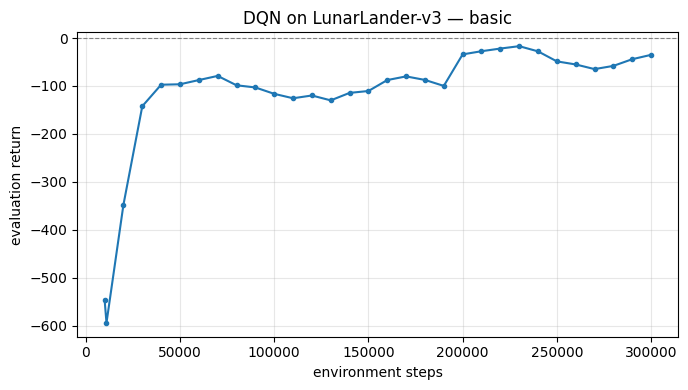

In [22]:
s, r, _ = train_dqn(total_frames=DQN_FRAMES, num_updates=DQN_UPDATES,
                    eval_step_freq=DQN_EVAL, label="basic")

plt.figure(figsize=(7, 4))
plt.plot(s, r, marker="o", ms=3)
plt.axhline(0, color="grey", lw=0.8, ls="--")
plt.xlabel("environment steps"); plt.ylabel("evaluation return")
plt.title("DQN on LunarLander-v3 — basic")
plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("dqn_1_basic.png", dpi=120); plt.show()